In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")

## Load dataset

In [6]:
customer_df = pd.read_csv(
    "../../data/processed/customer_segments.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

customer_df.head()

,customer_unique_id,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score,Cluster,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,1.0,12.00,141.90,5.0,6.0,2018-05-10,2018-05-10,0,116,1.0,0.084567,4,1,4,414,1,Regular Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,1.0,8.29,27.19,4.0,3.0,2018-05-07,2018-05-07,0,119,1.0,0.304892,4,1,1,411,4,Budget Customers
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,17.22,86.22,3.0,26.0,2017-03-10,2017-03-10,0,542,1.0,0.199722,1,1,2,112,2,Dissatisfied Customers
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,1.0,17.63,43.62,4.0,20.0,2017-10-12,2017-10-12,0,326,1.0,0.404172,2,1,1,211,4,Budget Customers
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,1.0,16.89,196.89,5.0,13.0,2017-11-14,2017-11-14,0,293,1.0,0.085784,2,1,4,214,1,Regular Customers


## Dataset information

In [7]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95419 entries, 0 to 95418
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   customer_unique_id      95419 non-null  str           
 1   total_orders            95419 non-null  int64         
 2   total_spent             95419 non-null  float64       
 3   total_products          95419 non-null  float64       
 4   total_freight_paid      95419 non-null  float64       
 5   avg_order_value         95419 non-null  float64       
 6   avg_review_score        94720 non-null  float64       
 7   avg_delivery_days       93355 non-null  float64       
 8   first_purchase          95419 non-null  datetime64[us]
 9   last_purchase           95419 non-null  datetime64[us]
 10  customer_lifetime_days  95419 non-null  int64         
 11  recency_days            95419 non-null  int64         
 12  avg_basket_size         95419 non-null  float64       
 1

In [8]:
customer_df.describe().T

,count,mean,min,25%,50%,75%,max,std
total_orders,95419.0,1.034018,1.0,1.0,1.0,1.0,16.0,0.211235
total_spent,95419.0,166.070491,9.59,63.1,107.95,183.27,13664.08,228.341907
total_products,95419.0,1.180551,1.0,1.0,1.0,1.0,24.0,0.621425
total_freight_paid,95419.0,23.600133,0.0,14.08,17.6,25.54,1794.96,22.878731
avg_order_value,95419.0,161.073799,9.59,62.44,105.78,177.15,13664.08,221.208569
avg_review_score,94720.0,4.102521,1.0,4.0,5.0,5.0,5.0,1.326359
avg_delivery_days,93355.0,12.506692,0.0,7.0,10.0,16.0,210.0,9.554535
first_purchase,95419,2017-12-30 19:40:56.529622,2016-09-04 00:00:00,2017-09-12 00:00:00,2018-01-19 00:00:00,2018-05-04 00:00:00,2018-08-29 00:00:00,NaN
last_purchase,95419,2018-01-02 12:05:03.788553,2016-09-04 00:00:00,2017-09-15 00:00:00,2018-01-22 00:00:00,2018-05-07 00:00:00,2018-09-03 00:00:00,NaN
customer_lifetime_days,95419.0,2.683417,0.0,0.0,0.0,0.0,633.0,25.263205


## Select Features

In [10]:
model_df = customer_df.drop(
    columns=[
        "customer_unique_id",
        "first_purchase",
        "last_purchase",
        "Customer_Segment",
        "Cluster"
    ]
)

model_df.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_order_value,avg_review_score,avg_delivery_days,customer_lifetime_days,recency_days,avg_basket_size,freight_ratio,R_score,F_score,M_score,RFM_score
0,1,141.90,1.0,12.00,141.90,5.0,6.0,0,116,1.0,0.084567,4,1,4,414
1,1,27.19,1.0,8.29,27.19,4.0,3.0,0,119,1.0,0.304892,4,1,1,411
2,1,86.22,1.0,17.22,86.22,3.0,26.0,0,542,1.0,0.199722,1,1,2,112
3,1,43.62,1.0,17.63,43.62,4.0,20.0,0,326,1.0,0.404172,2,1,1,211
4,1,196.89,1.0,16.89,196.89,5.0,13.0,0,293,1.0,0.085784,2,1,4,214


- Why remove Cluster and Customer_Segment initially?

- The segmentation model itself was built using these same customer features. Including cluster labels as predictors can introduce circular information. It's better to build a baseline churn model first, then later compare it with a version that includes Cluster as an additional feature.

## Create the Churn Label

In [11]:
model_df["recency_days"].describe()

count    95419.000000
mean       243.496484
std        153.153950
min          0.000000
25%        119.000000
50%        224.000000
75%        353.000000
max        729.000000
Name: recency_days, dtype: float64

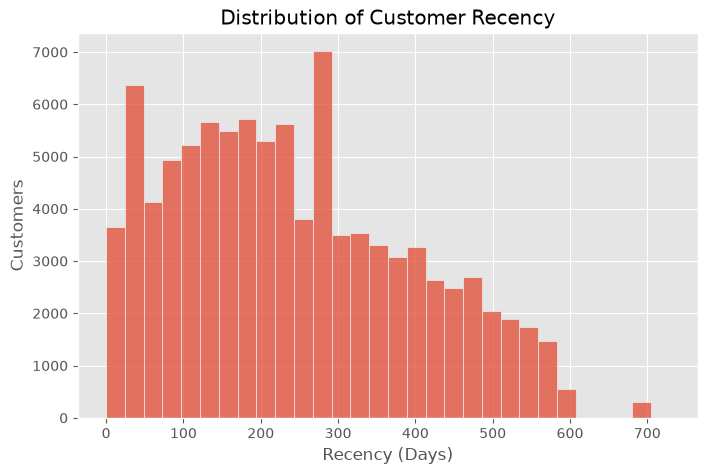

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    model_df["recency_days"],
    bins=30
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Customers")

plt.show()

### Decision

The Olist dataset spans roughly 2016–2018. A customer who has not purchased for one year is much more reasonably considered churned in this context.


In [13]:
(model_df["recency_days"] >= 365).mean() * 100

np.float64(23.231222293253964)

### Create the target

In [14]:
CHURN_THRESHOLD = 365

model_df["churn"] = (
    model_df["recency_days"] >= CHURN_THRESHOLD
).astype(int)

model_df["churn"].value_counts()

churn
0    73252
1    22167
Name: count, dtype: int64

In [15]:
(
    model_df["churn"]
    .value_counts(normalize=True)
    *100
).round(2)

churn
0    76.77
1    23.23
Name: proportion, dtype: float64

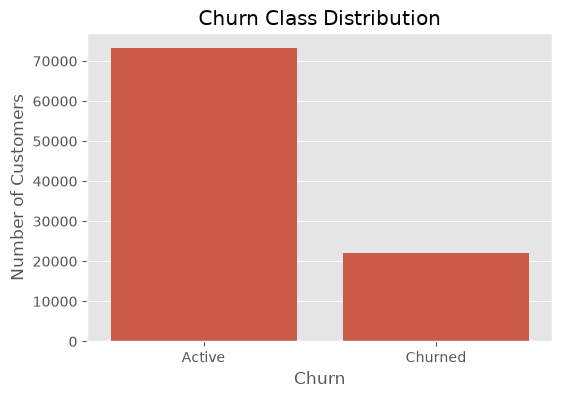

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=model_df,
    x="churn"
)

plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["Active", "Churned"])

plt.show()

## Churn Definition

The Olist dataset does not contain a predefined churn label. Therefore, a binary target variable was created using customer recency.

Customers whose most recent purchase occurred **365 days or more** before the reference date were labeled as **churned**, while customers with more recent purchases were labeled as **active**.

A one-year threshold was selected because it provides a realistic business definition of customer inactivity while maintaining a balanced class distribution for supervised machine learning.

### Checking Missing values

In [17]:
model_df.isnull().sum()

total_orders                 0
total_spent                  0
total_products               0
total_freight_paid           0
avg_order_value              0
avg_review_score           699
avg_delivery_days         2064
customer_lifetime_days       0
recency_days                 0
avg_basket_size              0
freight_ratio                0
R_score                      0
F_score                      0
M_score                      0
RFM_score                    0
churn                        0
dtype: int64

#### Now it  needs to handle the missing values, I  applied  the technique same as I did in customer segmentation data preparation

In [18]:
model_df["has_review"] = (
    model_df["avg_review_score"]
    .notna()
    .astype(int)
)

model_df["avg_review_score"] = (
    model_df["avg_review_score"]
    .fillna(model_df["avg_review_score"].median())
)

In [19]:
model_df["delivery_completed"] = (
    model_df["avg_delivery_days"]
    .notna()
    .astype(int)
)

model_df["avg_delivery_days"] = (
    model_df["avg_delivery_days"]
    .fillna(model_df["avg_delivery_days"].median())
)

In [20]:
model_df.isnull().sum()

total_orders              0
total_spent               0
total_products            0
total_freight_paid        0
avg_order_value           0
avg_review_score          0
avg_delivery_days         0
customer_lifetime_days    0
recency_days              0
avg_basket_size           0
freight_ratio             0
R_score                   0
F_score                   0
M_score                   0
RFM_score                 0
churn                     0
has_review                0
delivery_completed        0
dtype: int64

### Select Features

In [21]:
selected_features = [
    "total_orders",
    "total_spent",
    "total_products",
    "total_freight_paid",
    "avg_review_score",
    "avg_delivery_days",
    "customer_lifetime_days",
    "avg_basket_size",
    "freight_ratio",
    "has_review",
    "delivery_completed"
]

X = model_df[selected_features]

y = model_df["churn"]

In [22]:
print(X.shape)

X.head()

(95419, 11)


,total_orders,total_spent,total_products,total_freight_paid,avg_review_score,avg_delivery_days,customer_lifetime_days,avg_basket_size,freight_ratio,has_review,delivery_completed
0,1,141.90,1.0,12.00,5.0,6.0,0,1.0,0.084567,1,1
1,1,27.19,1.0,8.29,4.0,3.0,0,1.0,0.304892,1,1
2,1,86.22,1.0,17.22,3.0,26.0,0,1.0,0.199722,1,1
3,1,43.62,1.0,17.63,4.0,20.0,0,1.0,0.404172,1,1
4,1,196.89,1.0,16.89,5.0,13.0,0,1.0,0.085784,1,1


### Train-test-split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Verify the class distribution

In [24]:
print("Training Set")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Set")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training Set
churn
0    76.77
1    23.23
Name: proportion, dtype: float64

Testing Set
churn
0    76.77
1    23.23
Name: proportion, dtype: float64


### Create the final dataset

In [25]:
train_df = X_train.copy()
train_df["churn"] = y_train

test_df = X_test.copy()
test_df["churn"] = y_test

In [26]:
train_df.head()

,total_orders,total_spent,total_products,total_freight_paid,avg_review_score,avg_delivery_days,customer_lifetime_days,avg_basket_size,freight_ratio,has_review,delivery_completed,churn
36727,1,158.74,1.0,31.76,4.0,10.0,0,1.0,0.200076,1,1,0
46684,1,155.63,1.0,15.73,1.0,14.0,0,1.0,0.101073,1,1,1
78995,1,1069.41,1.0,70.41,1.0,14.0,0,1.0,0.065840,1,1,0
17260,1,386.46,1.0,17.46,5.0,8.0,0,1.0,0.045179,1,1,0
42719,1,112.97,1.0,38.07,1.0,27.0,0,1.0,0.336992,1,1,1


### Save the prepared data

In [27]:
train_df.to_csv(
    "../../data/processed/customer_churn_data/churn_train.csv",
    index=False
)

test_df.to_csv(
    "../../data/processed/customer_churn_data/churn_test.csv",
    index=False
)

## Feature Selection

To reduce feature redundancy and avoid target leakage, only behavioral and transactional customer attributes were selected for churn prediction.

The final feature set includes:

- total_orders
- total_spent
- total_products
- total_freight_paid
- avg_review_score
- avg_delivery_days
- customer_lifetime_days
- avg_basket_size
- freight_ratio
- has_review
- delivery_completed

Engineered RFM features (`R_score`, `F_score`, `M_score`, `RFM_score`) and `recency_days` were excluded because they are directly related to the rule used to define the churn target, which could lead to target leakage and overly optimistic model performance.